# Verify DC2-Matching Convergence Maps

Compare sbi_lens lognormal maps (generated with DC2 geometry: N=64, map_size=0.91, cropped to 64×40) against DC2 true convergence maps from the images_to_maps encoder.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from functools import partial

plt.rcParams["font.family"] = "serif"

## 1. Generate sbi_lens maps with DC2 settings

In [2]:
import jax
import jax.numpy as jnp
from jax import random, vmap
from numpyro.handlers import condition, seed, trace
from sbi_lens.simulator.LogNormal_field import lensingLogNormal

# DC2 geometry settings
N = 64
map_size = 0.91
crop_width = 40
nbins = 5

model = partial(
    lensingLogNormal,
    N=N,
    map_size=map_size,
    gal_per_arcmin2=27.0,
    sigma_e=0.26,
    nbins=nbins,
    a=2.0,
    b=0.68,
    z0=0.11,
    model_type="lognormal",
    lognormal_shifts="LSSTY10",
    with_noise=False,
)

# WMAP-7 cosmology (DC2 truth)
wmap7_params = {
    "omega_c": jnp.array(0.22),
    "omega_b": jnp.array(0.048),
    "sigma_8": jnp.array(0.80),
    "h_0": jnp.array(0.71),
    "n_s": jnp.array(0.963),
    "w_0": jnp.array(-1.0),
}

# Generate a few maps
n_samples = 4
key = random.PRNGKey(0)
sbi_maps = []
for i in range(n_samples):
    key, subkey = random.split(key)
    model_trace = trace(seed(condition(model, data=wmap7_params), subkey)).get_trace()
    kappa = model_trace["y"]["value"]
    # Crop width to 40: output is (height, width, bins) = (64, 64, 5) -> (64, 40, 5)
    kappa = kappa[:, :crop_width, :]
    sbi_maps.append(np.array(kappa))

sbi_maps = np.stack(sbi_maps)
print(f"sbi_lens maps shape: {sbi_maps.shape}  (samples, height, width, bins)")

/home/twhit/blissWL/.venv/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


sbi_lens maps shape: (4, 64, 40, 5)  (samples, height, width, bins)


## 2. Load DC2 true convergence maps

In [3]:
from hydra import compose, initialize
from hydra.utils import instantiate
import lightning as L
from lightning.pytorch.utilities import move_data_to_device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

ckpt = "/data/scratch/twhit/checkpoints/trained_encoder_dc2.ckpt"

with initialize(config_path="../../images_to_maps/dc2/", version_base=None):
    cfg = compose(
        "config_train_npe",
        {
            "train.pretrained_weights=" + ckpt,
        },
    )

data_source = instantiate(cfg.train.data_source)
data_source.setup("test")
test_dl = data_source.test_dataloader()

# Collect DC2 true convergence maps and RA/DEC (same as posteriormeanmaps.ipynb)
num_tiles_per_side = 8
num_dc2_bins = 4
convergence_true = torch.zeros(
    len(test_dl), num_tiles_per_side, num_tiles_per_side, num_dc2_bins, device=device
)
ra = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_dc2_bins, device=device)
dec = torch.zeros(len(test_dl), num_tiles_per_side, num_tiles_per_side, num_dc2_bins, device=device)

for i, b in enumerate(test_dl):
    batch = move_data_to_device(b, device)
    convergence_true[i] = batch["tile_catalog"]["convergence"].squeeze()
    ra[i] = batch["tile_catalog"]["ra"].squeeze()
    dec[i] = batch["tile_catalog"]["dec"].squeeze()

print(f"DC2 convergence shape (per entry): {convergence_true.shape}")

# Sort by RA/DEC to assemble into a spatially-correct map (from posteriormeanmaps.ipynb)
ra_mean = ra.mean([1, 2, 3])
dec_mean = dec.mean([1, 2, 3])

dec_sort_idx = torch.argsort(dec_mean)
dec_bins = dec_sort_idx.view(8, 5)

sorted_indices = torch.zeros_like(dec_bins)
for i in range(8):
    ra_in_row = ra_mean[dec_bins[i]]
    ra_sort_idx = torch.argsort(-ra_in_row)
    sorted_indices[i] = dec_bins[i][ra_sort_idx]

idx = sorted_indices.flatten()

# Rearrange into full map: (8 dec_rows, 5 ra_cols, 8, 8, 4) -> (64, 40, 4)
dc2_map = rearrange(
    convergence_true[idx].view(8, 5, num_tiles_per_side, num_tiles_per_side, num_dc2_bins),
    "h w nh nw b -> (h nh) (w nw) b",
).cpu().numpy()

print(f"DC2 assembled map shape: {dc2_map.shape}  (height, width, bins) = (64, 40, 4)")

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


DC2 convergence shape (per entry): torch.Size([40, 8, 8, 4])
DC2 assembled map shape: (64, 40, 4)  (height, width, bins) = (64, 40, 4)


## 3. Side-by-side comparison

/tmp/ipykernel_1059267/2152661643.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


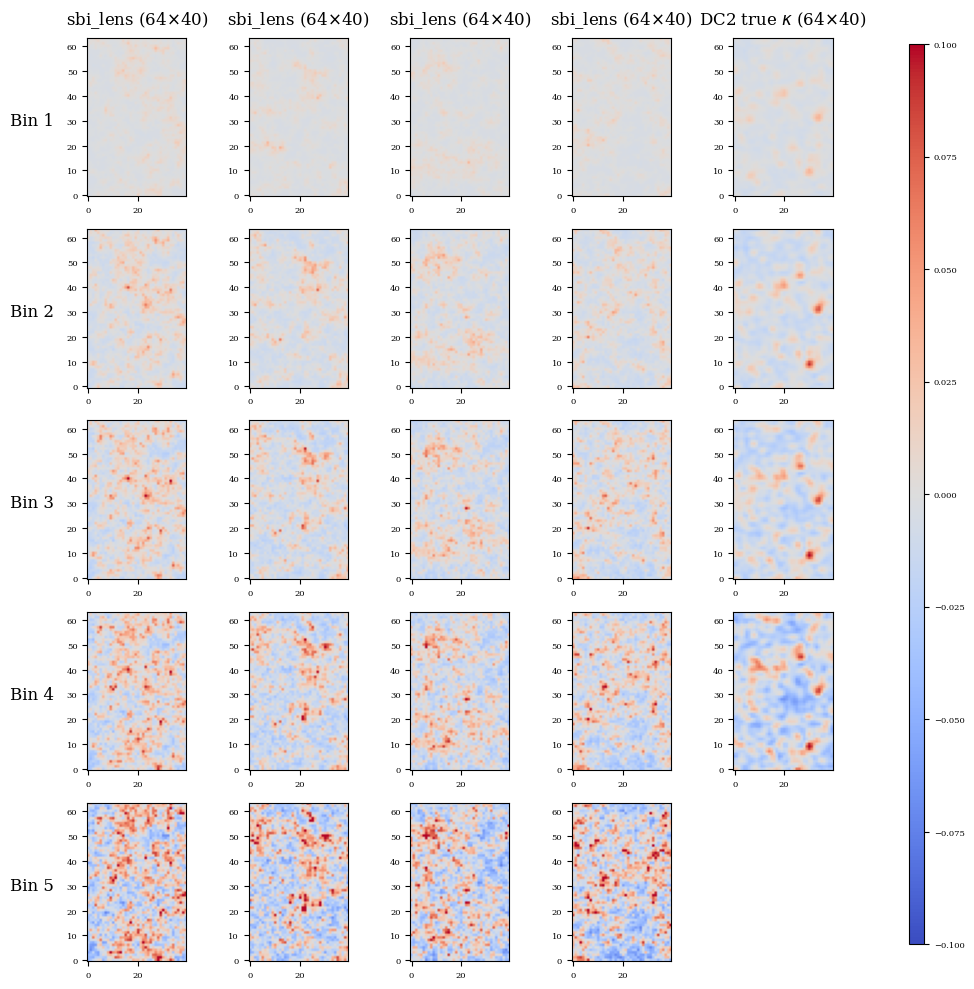

In [4]:
fontsize = 12
ticklabelsize = 6
vmin = -0.1
vmax = 0.1
cmap = "coolwarm"

# Compare: sbi_lens (5 bins, 64x40) vs DC2 (4 bins, 64x40)
n_rows = max(nbins, num_dc2_bins)
fig, ax = plt.subplots(n_rows, 5, figsize=(10, 2 * n_rows))

for b in range(n_rows):
    # sbi_lens map 1
    if b < nbins:
        ax[b, 0].imshow(
            sbi_maps[0, :, :, b],
            origin="lower",
            vmin=vmin, vmax=vmax, cmap=cmap,
        )
    else:
        ax[b, 0].axis("off")

    # sbi_lens map 2
    if b < nbins:
        ax[b, 1].imshow(
            sbi_maps[1, :, :, b],
            origin="lower",
            vmin=vmin, vmax=vmax, cmap=cmap,
        )
    else:
        ax[b, 1].axis("off")

    # sbi_lens map 3
    if b < nbins:
        ax[b, 2].imshow(
            sbi_maps[2, :, :, b],
            origin="lower",
            vmin=vmin, vmax=vmax, cmap=cmap,
        )
    else:
        ax[b, 2].axis("off")

    # sbi_lens map 3
    if b < nbins:
        ax[b, 3].imshow(
            sbi_maps[3, :, :, b],
            origin="lower",
            vmin=vmin, vmax=vmax, cmap=cmap,
        )
    else:
        ax[b, 3].axis("off")
    
    # DC2 map
    if b < num_dc2_bins:
        im = ax[b, 4].imshow(
            dc2_map[:, :, b],
            origin="lower",
            vmin=vmin, vmax=vmax, cmap=cmap,
        )
    else:
        ax[b, 4].axis("off")

    ax[b, 0].set_ylabel(f"Bin {b+1}", fontsize=fontsize, rotation=0, labelpad=25, y=0.425)
    for a in ax[b]:
        a.tick_params(axis="both", which="major", labelsize=ticklabelsize)

ax[0, 0].set_title(r"sbi_lens (64$\times$40)", fontsize=fontsize, pad=10)
ax[0, 1].set_title(r"sbi_lens (64$\times$40)", fontsize=fontsize, pad=10)
ax[0, 2].set_title(r"sbi_lens (64$\times$40)", fontsize=fontsize, pad=10)
ax[0, 3].set_title(r"sbi_lens (64$\times$40)", fontsize=fontsize, pad=10)
ax[0, 4].set_title(r"DC2 true $\kappa$ (64$\times$40)", fontsize=fontsize, pad=10)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.925, 0.05, 0.015, 0.9])
cbar_ax.tick_params(labelsize=ticklabelsize)
fig.colorbar(im, cax=cbar_ax)

fig.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

## 4. Pixel value histograms

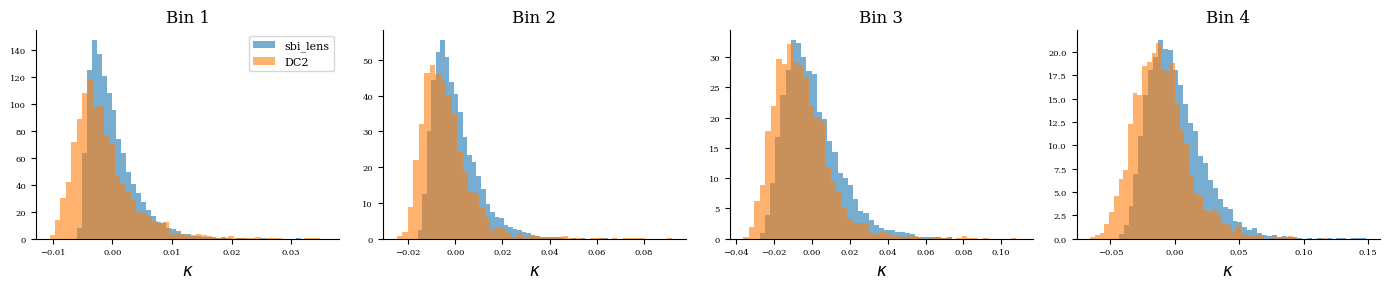

In [5]:
fig, axes = plt.subplots(1, min(nbins, num_dc2_bins), figsize=(3.5 * min(nbins, num_dc2_bins), 3))

for b in range(min(nbins, num_dc2_bins)):
    ax = axes[b]
    ax.hist(
        sbi_maps[:, :, :, b].flatten(), bins=50, alpha=0.6,
        label="sbi_lens", density=True,
    )
    ax.hist(
        dc2_map[:, :, b].flatten(), bins=50, alpha=0.6,
        label="DC2", density=True,
    )
    ax.set_title(f"Bin {b+1}", fontsize=fontsize)
    ax.set_xlabel(r"$\kappa$", fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=ticklabelsize)
    ax.spines[["top", "right"]].set_visible(False)
    if b == 0:
        ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Value range comparison

In [6]:
print("Value ranges per redshift bin:")
print(f"{'Bin':>4}  {'sbi_lens min':>14}  {'sbi_lens max':>14}  {'DC2 min':>14}  {'DC2 max':>14}")
for b in range(min(nbins, num_dc2_bins)):
    sbi_vals = sbi_maps[:, :, :, b]
    dc2_vals = dc2_map[:, :, b]
    print(f"{b+1:>4}  {sbi_vals.min():>14.6f}  {sbi_vals.max():>14.6f}  {dc2_vals.min():>14.6f}  {dc2_vals.max():>14.6f}")

print("\nStandard deviations per bin:")
print(f"{'Bin':>4}  {'sbi_lens std':>14}  {'DC2 std':>14}")
for b in range(min(nbins, num_dc2_bins)):
    print(f"{b+1:>4}  {sbi_maps[:, :, :, b].std():>14.6f}  {dc2_map[:, :, b].std():>14.6f}")

Value ranges per redshift bin:
 Bin    sbi_lens min    sbi_lens max         DC2 min         DC2 max
   1       -0.005956        0.035746       -0.010489        0.034874
   2       -0.015966        0.079976       -0.024924        0.092058
   3       -0.027699        0.109549       -0.036240        0.107856
   4       -0.043607        0.148689       -0.065575        0.117206

Standard deviations per bin:
 Bin    sbi_lens std         DC2 std
   1        0.004003        0.005233
   2        0.009579        0.011061
   3        0.015010        0.014979
   4        0.021719        0.021880


## 6. Smail n(z) vs DC2 n(z)

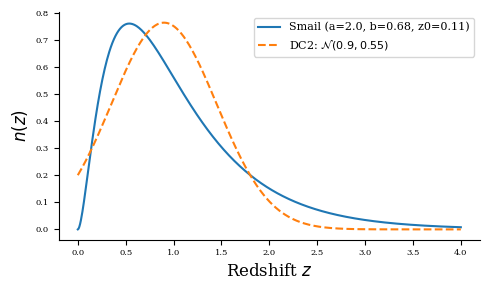

In [7]:
from scipy.stats import norm

z = np.linspace(0, 4, 500)

# Smail distribution: n(z) ~ z^a * exp(-(z/z0)^b)
a, b_smail, z0 = 2.0, 0.68, 0.11
smail_nz = z**a * np.exp(-(z / z0) ** b_smail)
smail_nz /= np.trapezoid(smail_nz, z)

# DC2 n(z): Normal(0.9, 0.55), truncated at z > 0
dc2_nz = norm.pdf(z, loc=0.9, scale=0.55)
dc2_nz[z < 0] = 0
dc2_nz /= np.trapezoid(dc2_nz, z)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(z, smail_nz, label=f"Smail (a={a}, b={b_smail}, z0={z0})")
ax.plot(z, dc2_nz, label=r"DC2: $\mathcal{N}(0.9, 0.55)$", linestyle="--")
ax.set_xlabel("Redshift $z$", fontsize=fontsize)
ax.set_ylabel("$n(z)$", fontsize=fontsize)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", which="major", labelsize=ticklabelsize)
fig.tight_layout()
plt.show()